## 2장 2강: 경사하강법, 옵티마이저 및 데이터 분할

In [1]:
import sklearn
import pandas as pd
sklearn.set_config(display='text')

df = pd.read_csv("usa_housing.csv")
df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,4827,1979,2,1.45,82240,48.60,5
1,771155,2,2.0,1035,1987,2,1.75,74315,92.03,9
2,231932,1,3.0,2769,1982,1,1.46,79249,52.08,3
3,465838,3,3.3,2708,1907,3,1.62,80587,61.65,1
4,359178,4,3.4,1175,1994,2,0.74,20756,15.66,4


In [3]:
X = df[['SquareFeet', 'CrimeRate', 'SchoolRating']]
y = df['Price'] # 정답(Label), 종속변수

X.head()

,SquareFeet,CrimeRate,SchoolRating
0,4827,48.60,5
1,1035,92.03,9
2,2769,52.08,3
3,2708,61.65,1
4,1175,15.66,4


In [17]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [18]:
print("가중치:", model.coef_)
print("절편:", model.intercept_)

가중치: [  17.64218384  165.54335017 2753.89459814]
절편: 446703.79143559677


In [19]:
y_pred = model.predict(X)

y_pred[:10]


array([553677.4926239 , 504983.45760631, 512438.17995057, 507438.46740142,
       481041.34469987, 548602.92327148, 520154.49162671, 503931.32583249,
       521323.66394383, 535128.29765563])

In [20]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

min_max_scaler = MinMaxScaler()
min_max_scaler.fit(X.values) # 준비(기준)

X_scaled1 = min_max_scaler.transform(X.values) # 변환 (0~1)

X_scaled1[:10]

array([[0.95910512, 0.48643489, 0.5       ],
       [0.04690883, 0.92282958, 1.        ],
       [0.46403656, 0.52140273, 0.25      ],
       [0.44936252, 0.61756431, 0.        ],
       [0.08058696, 0.15544614, 0.375     ],
       [0.83954775, 0.04200161, 1.        ],
       [0.62424826, 0.10942524, 0.375     ],
       [0.36805389, 0.59947749, 0.125     ],
       [0.6062064 , 0.09354904, 0.5       ],
       [0.80611018, 0.37590434, 0.25      ]])

In [21]:
ss = StandardScaler()
ss.fit(X.values) # 변환 준비

X_scaled2 = ss.transform(X.values) # 표준점수로 변환
X_scaled2[:10]

array([[ 1.48724433, -0.02515304, -0.03620875],
       [-1.69135536,  1.48361236,  1.4620844 ],
       [-0.23785012,  0.09574274, -0.78535533],
       [-0.28898266,  0.42820612, -1.5345019 ],
       [-1.57400199, -1.16949409, -0.41078204],
       [ 1.07063989, -1.56171056,  1.4620844 ],
       [ 0.3204166 , -1.32860405, -0.41078204],
       [-0.57230721,  0.36567383, -1.15992862],
       [ 0.25754872, -1.38349351, -0.03620875],
       [ 0.95412476, -0.40729486, -0.78535533]])

In [22]:
model = LinearRegression()
model.fit(X_scaled2, y.values)

LinearRegression()

In [23]:
model = LinearRegression()
model.fit(X_scaled2, y.values)

LinearRegression()

In [9]:
print("가중치:", model.coef_)
print("절편:", model.intercept_)

가중치: [  17.64218384  165.54335017 2753.89459814]
절편: 446703.79143559677


### 4. 데이터 분할 및 경사하강법 시각화
#### 4.1 오버슈팅 방지! 데이터 스케일링(Scaling)과 분할하기

머신러닝 데이터 가공과 시각화에 필요한 필수 도구들을 불러옵니다.

In [10]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt 

미국 주택 데이터(usa_housing.csv) 불러오기

In [11]:
df = pd .read_csv("usa_housing.csv")
df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
0,221958,1,1.9,4827,1979,2,1.45,82240,48.60,5
1,771155,2,2.0,1035,1987,2,1.75,74315,92.03,9
2,231932,1,3.0,2769,1982,1,1.46,79249,52.08,3
3,465838,3,3.3,2708,1907,3,1.62,80587,61.65,1
4,359178,4,3.4,1175,1994,2,0.74,20756,15.66,4


데이터 전처리: 최근 데이터 + 범죄율이 낮은 데이터로 필터링

In [12]:
df = df[(df['YearBuilt'] > 2015 ) & (df['CrimeRate'] < 40)]
df.head()

,Price,Bedrooms,Bathrooms,SquareFeet,YearBuilt,GarageSpaces,LotSize,ZipCode,CrimeRate,SchoolRating
9,737147,3,2.6,4191,2017,0,1.65,66549,37.60,3
33,586232,4,1.3,3854,2021,2,1.39,30103,26.93,2
112,616588,2,1.2,3872,2016,0,0.17,61112,20.98,8
119,979858,5,3.8,4307,2020,0,0.38,41822,37.14,4
189,161087,5,2.4,964,2021,1,0.24,34022,12.80,3


우리가 예측할 문제(Feature)와 정답(Label)을 세로로 긴 표(2차원) 형태로 뽑아냅니다.

In [26]:
X_sqft = df[['SquareFeet']].values
y_price = df['Price'].values

X_sqft.shape, y_price.shape

((10, 1), (10,))

데이터 스케일링 (숫자 압축하기)

- 정규화
= 표준점수(Z-score, StandardScaler)

In [52]:
ss = StandardScaler()

#ss.fit(X_sqft)
#X_scaled = ss.transform(X_sqft)
X_scaled = ss.fit_transform(X_sqft).flatten()

X_scaled

array([ 0.97965695,  0.65953245,  0.67663109,  1.08984817, -2.08574882,
       -1.34575778, -0.7644041 ,  0.20261886,  0.2824125 ,  0.30521068])

데이터 쪼개기 (Train 60%, Valid 20%, Test 20%)

In [51]:
#1차 분할 - 테스트
X_train_tmp, X_test, y_train_tmp, y_test = train_test_split(
    X_scaled, y_price, test_size=0.2, random_state=42
)

# 2차 분할 = 검증 세트(20%)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_tmp, y_train_tmp, test_size=0.2, random_state=42
)


print(f"전체 주택 데이터 수: {len(X_scaled)}채")
print(f"훈련(Train)용 주택: {len(X_train)}채")
print(f"검증(Valid)용 주택: {len(X_valid)}채")
print(f"테스트(Test)용 주택: {len(X_test)}채")

전체 주택 데이터 수: 10채
훈련(Train)용 주택: 6채
검증(Valid)용 주택: 2채
테스트(Test)용 주택: 2채


#### 4.2 AI 모델 최적화 학습 및 시각화

경사하강법을 위한 하이퍼파라미터 초기 세팅

In [41]:
import numpy as np

weight = 0.0          # 가중치(w): 집 크기에 따른 가격 영향력 (초기값 0)
bias = 0.0            # 편향(b): 기본적으로 깔고 가는 베이스 집값 (초기값 0)
learning_rate = 0.1   # 보폭(학습률): 스케일링을 했으므로 보폭을 조금 넓게 잡아도 안전합니다!
epochs = 200          # 훈련 횟수: 산을 내려가는 걸음을 총 200번 반복합니다.

# 훈련 과정에서 오차가 어떻게 줄어드는지 기록할 빈 리스트(수첩)를 만듭니다.
train_losses = []
valid_losses = []
history_w = []

N_train = len(X_train)
N_valid = len(X_valid)

 경사하강법 루프 시작 (200번 반복)

In [47]:
# 경사하강법 루프 시작 (200번 반복)
for epoch in range(epochs):
    # 훈련 세트: 현재 가중치로 집값을 예측해 봅니다 (y_pred = w * x + b)
    y_pred_train = weight * X_train + bias
    # 예측 집값과 실제 집값 차이의 제곱 평균(MSE Loss)을 구합니다.
    train_loss = np.mean((y_pred_train - y_train) ** 2)
    train_losses.append(train_loss)
    
    # 검증 세트: 모의고사 데이터를 넣어 현재 실력을 중간 점검합니다.
    y_pred_valid = weight * X_valid + bias
    valid_loss = np.mean((y_pred_valid - y_valid) ** 2)
    valid_losses.append(valid_loss)
    history_w.append(weight)
    
    # 기울기(Gradient) 구하기: 어느 방향으로 가야 오차가 줄어들지 미분 공식으로 찾습니다.
    dw = (2 / N_train) * np.sum((y_pred_train - y_train) * X_train)
    db = (2 / N_train) * np.sum(y_pred_train - y_train)
    
    # 한 걸음 이동! (현재 위치 - 보폭 * 기울기)
    weight -= learning_rate * dw
    bias -= learning_rate * db

인공지능이 길을 찾아간 과정을 그래프로 시각화하기

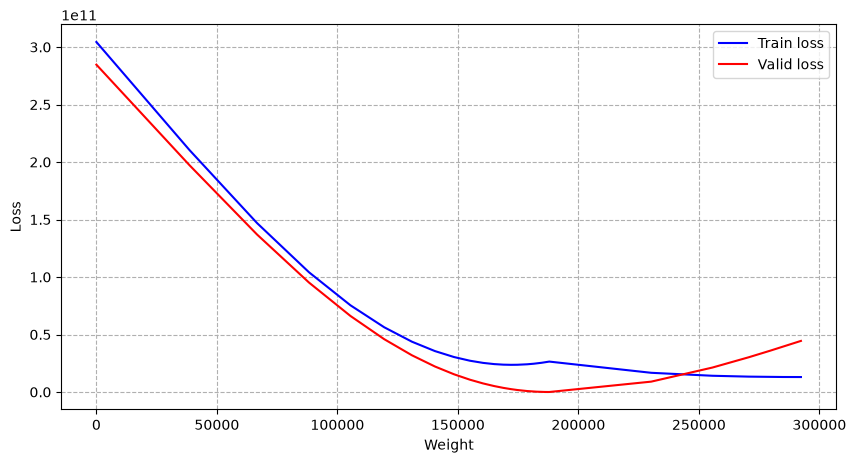

In [48]:
plt.figure(figsize=(10, 5))

plt.plot(history_w, train_losses, color='blue', label='Train loss')
plt.plot(history_w, valid_losses, color='red', label='Valid loss')
plt.xlabel("Weight")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle='--')
plt.show()